# Post-Fire Landslide Susceptibility Modeling — Nacimiento, Chile
### Final Interactive Map

**Author:** Constanza Morales Gajardo
**Part of:** Landslide Susceptibility Portfolio Project (P5)

## 1. Introduction

This notebook builds the final interactive map for the post-fire landslide susceptibility model, publishing the classified susceptibility raster as a static, permanent HTML map (following the project's established pattern of exporting GEE/raster layers as static GeoTIFFs and rebuilding maps with Folium + rasterio, to avoid dependency on temporary tile URLs).

- **Input:** `outputs/nacimiento_landslide_susceptibility.tif`
- **Tools:** folium, rasterio, numpy

In [1]:
import folium
import rasterio
import numpy as np
from rasterio.warp import transform_bounds

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Final Susceptibility Raster

In [2]:
# Load the final classified susceptibility raster
raster_path = '../outputs/nacimiento_landslide_susceptibility.tif'

with rasterio.open(raster_path) as src:
    susceptibility = src.read(1)
    raster_crs = src.crs
    raster_bounds = src.bounds

# Reproject bounds to WGS84 (lat/lon) for Folium
bounds_wgs84 = transform_bounds(raster_crs, 'EPSG:4326', *raster_bounds)
minx, miny, maxx, maxy = bounds_wgs84

print(f"Raster loaded: shape {susceptibility.shape}")
print(f"Bounds (WGS84): {bounds_wgs84}")

# Calculate center point for map initialization
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2
print(f"Map center: {center_lat}, {center_lon}")

Raster loaded: shape (1317, 1767)
Bounds (WGS84): (-73.07103133543536, -37.63060691482359, -72.5948344033236, -37.27568254606796)
Map center: -37.45314473044577, -72.83293286937948


## 3. Convert Raster to Colored Image Overlay

The classified raster is converted into an RGBA image, applying the same color scheme used throughout the project (green→yellow→orange→red for susceptibility classes), with transparency for no-data areas outside the study area boundary.

In [3]:
# Define color scheme (RGBA) for each susceptibility class
color_map = {
    0: (0, 0, 0, 0),          # No data - fully transparent
    1: (26, 150, 65, 180),    # Very Low - dark green
    2: (145, 207, 96, 180),   # Low - light green
    3: (254, 224, 139, 180),  # Moderate - yellow
    4: (252, 141, 89, 180),   # High - orange
    5: (215, 48, 39, 180),    # Very High - red
}

# Build RGBA image
height, width = susceptibility.shape
rgba_image = np.zeros((height, width, 4), dtype=np.uint8)

for class_value, color in color_map.items():
    mask = susceptibility == class_value
    rgba_image[mask] = color

print(f"RGBA image created: shape {rgba_image.shape}")

RGBA image created: shape (1317, 1767, 4)


## 4. Build Interactive Map with Folium

Following the project's standard map style: Esri satellite basemap with CartoDB labels on top, static image overlay (no dependency on temporary GEE tiles), and a custom legend.


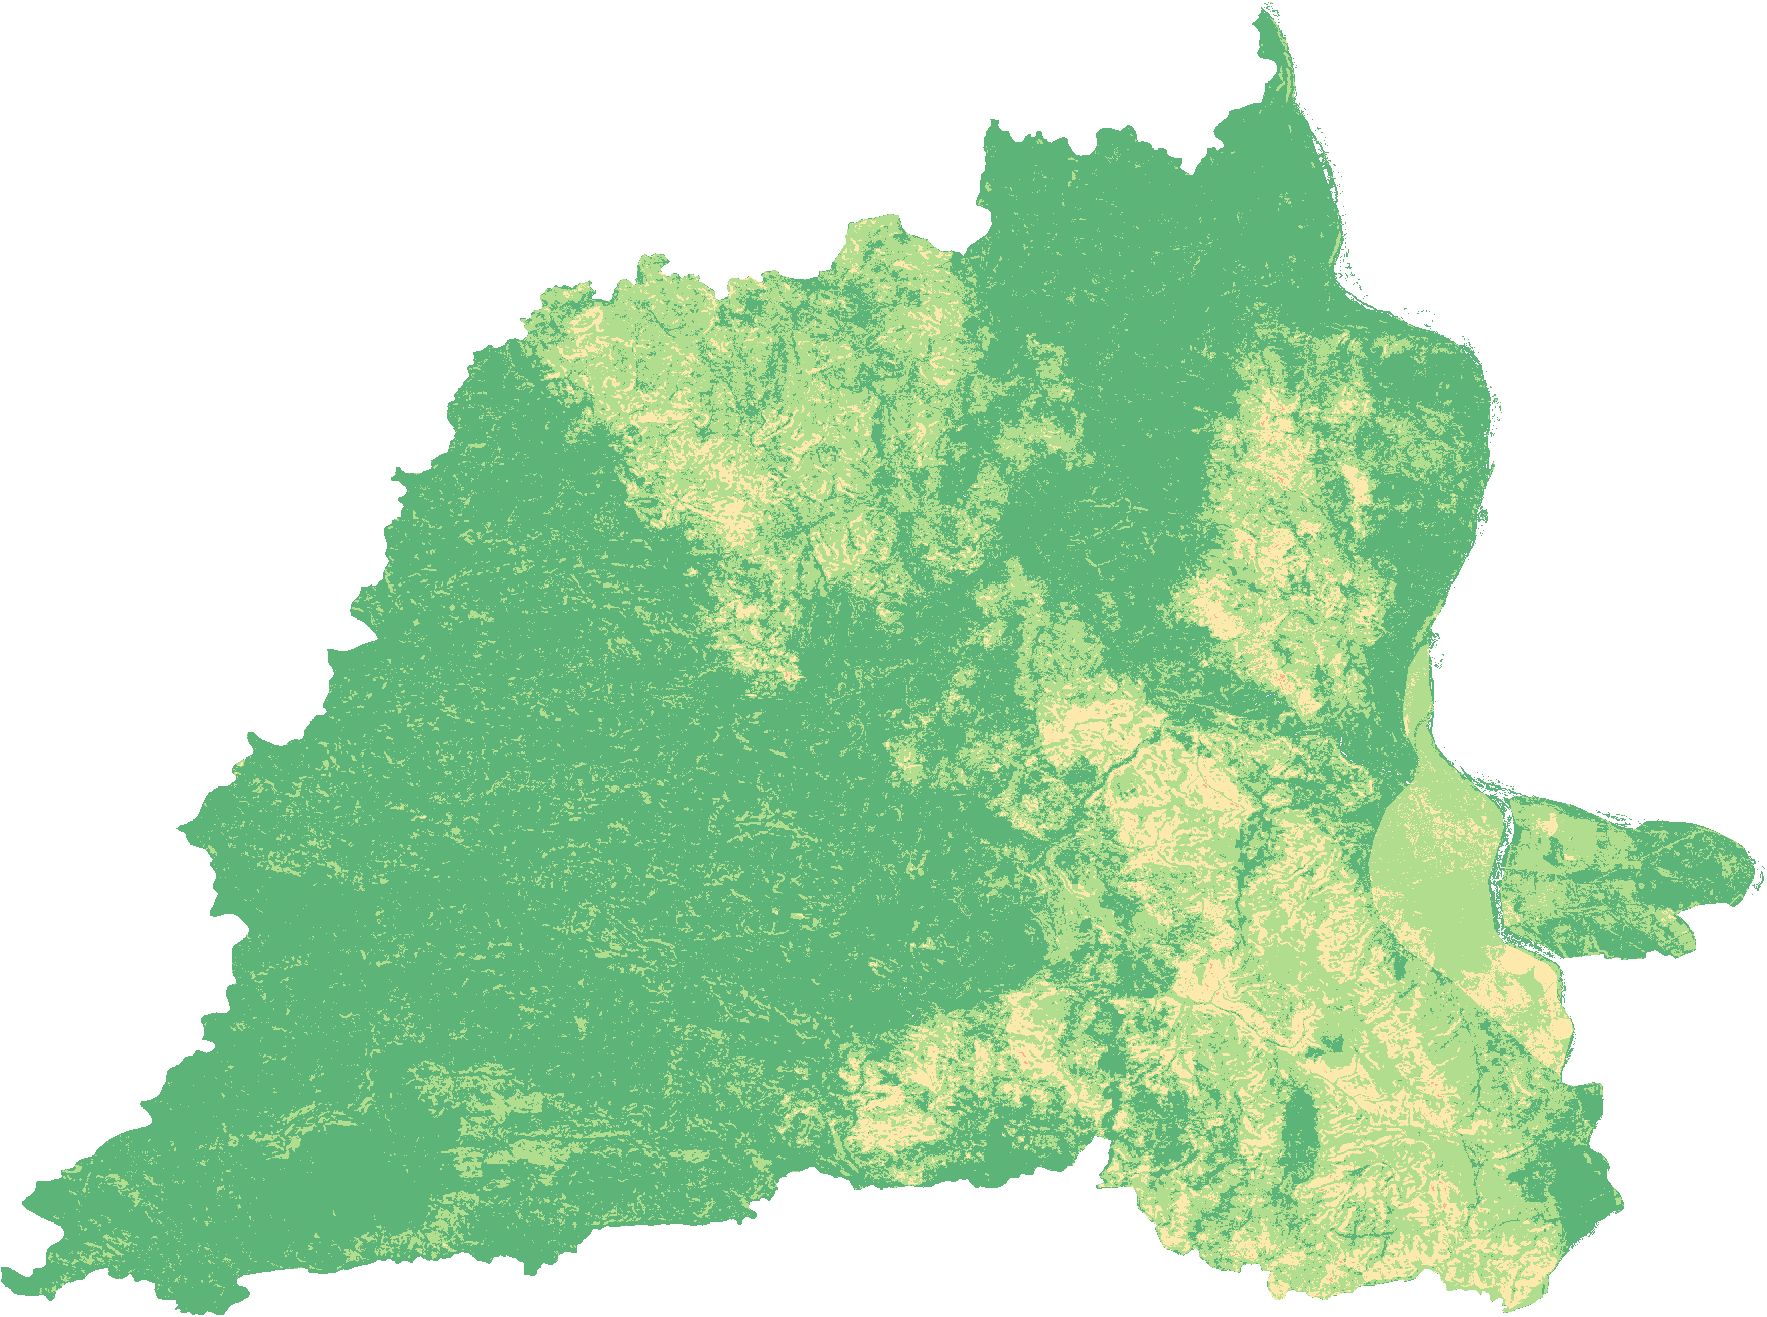

In [4]:
# Build the Folium map
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles=None)

# Esri satellite basemap (permanent)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Satellite'
).add_to(m)

# Labels on top
folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}{r}.png',
    attr='CartoDB', name='Labels', overlay=True
).add_to(m)

# Add the susceptibility raster as an image overlay
folium.raster_layers.ImageOverlay(
    image=rgba_image,
    bounds=[[miny, minx], [maxy, maxx]],
    opacity=0.8,
    name='Landslide Susceptibility'
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m

## 5. Add Legend


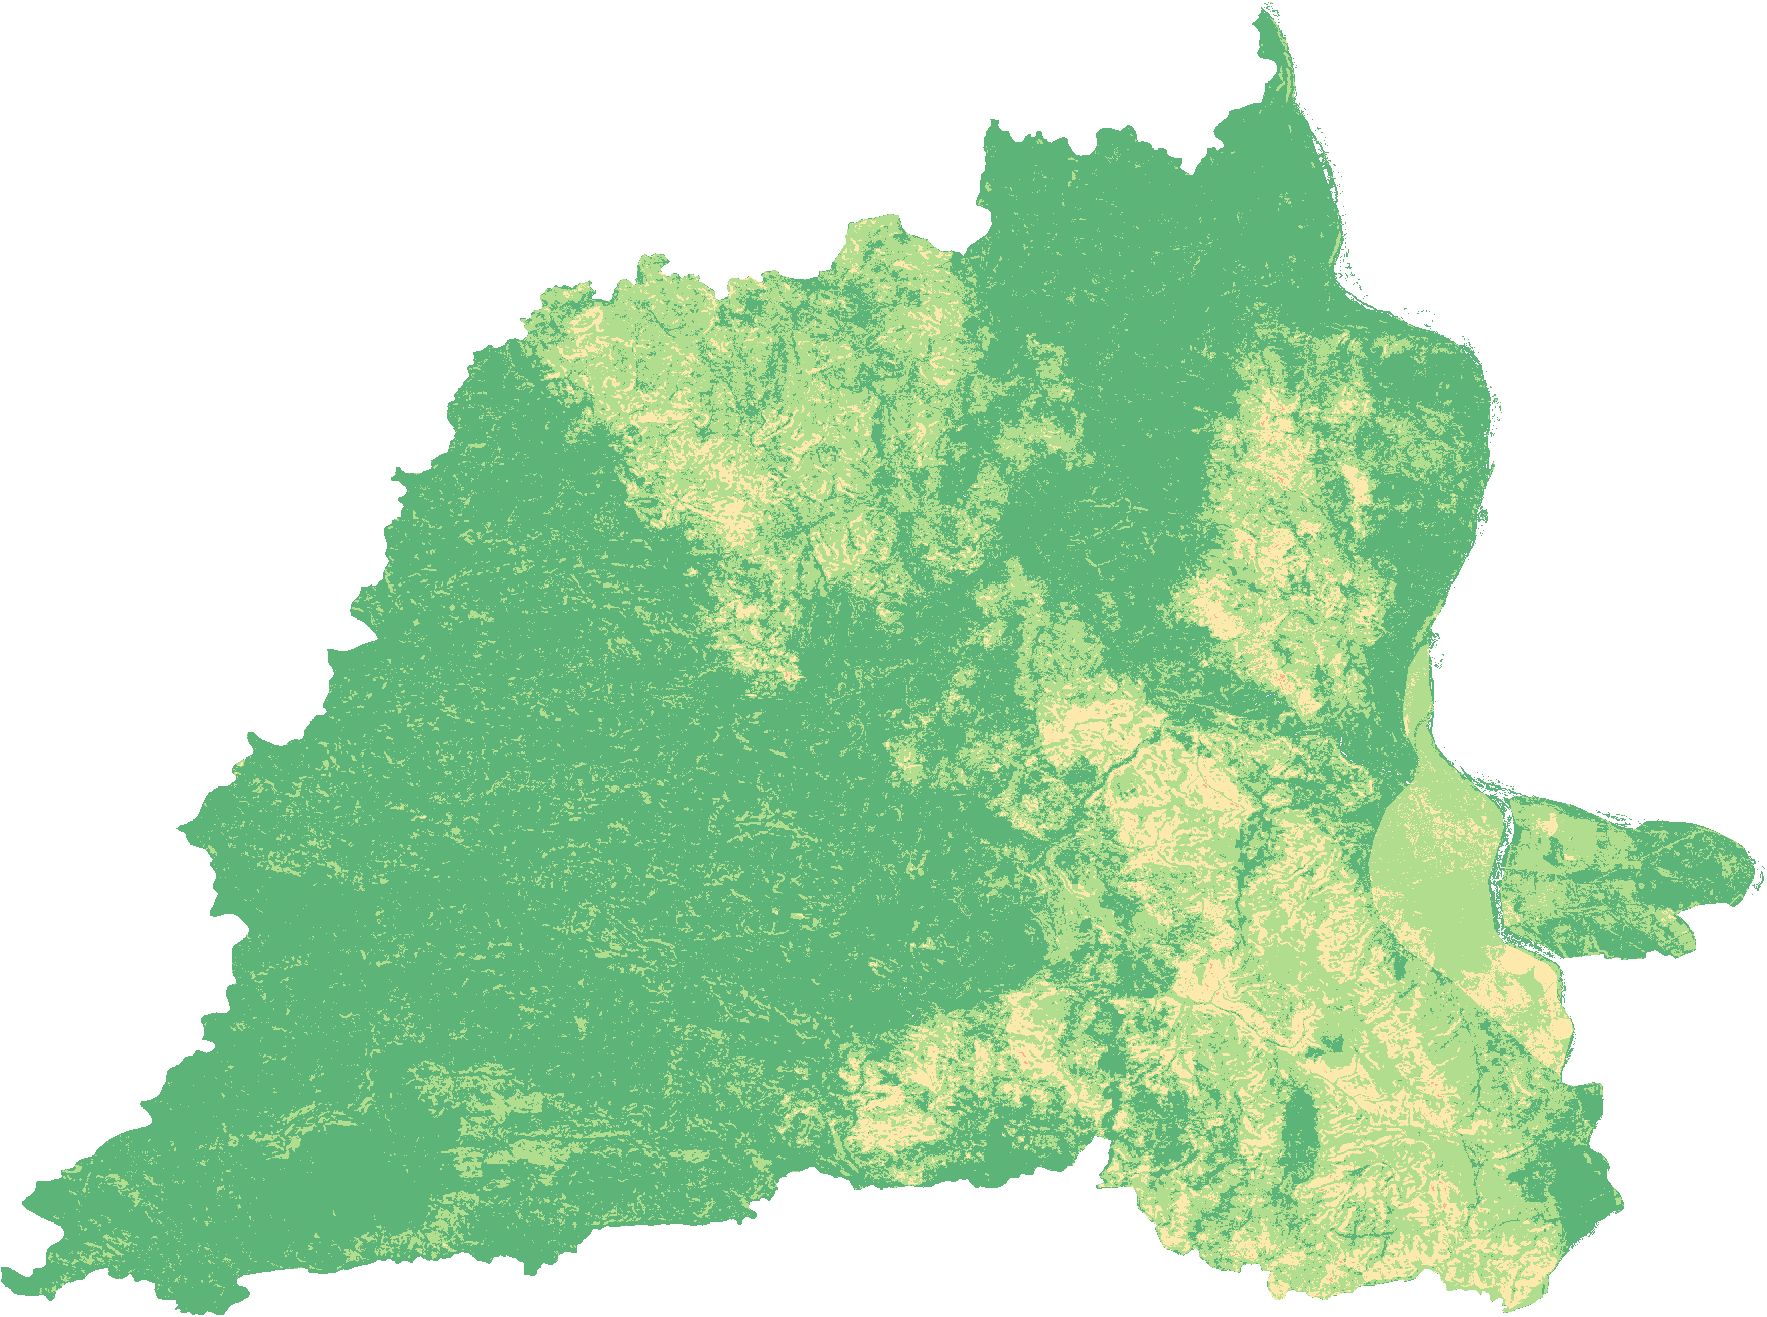

In [5]:
# Add a custom HTML legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; left: 50px; width: 180px; 
            background-color: white; z-index:9999; 
            border:2px solid grey; border-radius: 6px;
            padding: 10px; font-size: 14px;">
<b>Landslide Susceptibility</b><br>
<i style="background: #1a9850; width: 15px; height: 15px; display: inline-block; opacity: 0.8;"></i> Very Low<br>
<i style="background: #91cf60; width: 15px; height: 15px; display: inline-block; opacity: 0.8;"></i> Low<br>
<i style="background: #fee08b; width: 15px; height: 15px; display: inline-block; opacity: 0.8;"></i> Moderate<br>
<i style="background: #fc8d59; width: 15px; height: 15px; display: inline-block; opacity: 0.8;"></i> High<br>
<i style="background: #d73027; width: 15px; height: 15px; display: inline-block; opacity: 0.8;"></i> Very High<br>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))
m

## 6. Save Map as Static HTML

Saving to the repository root (not `notebooks/`) so it can be served directly via GitHub Pages.

In [6]:
# Save map to repository root
m.save('../nacimiento_landslide_susceptibility_map.html')

print("Map saved to repository root: nacimiento_landslide_susceptibility_map.html")

Map saved to repository root: nacimiento_landslide_susceptibility_map.html


## Conclusions

- Final post-fire landslide susceptibility map built as a static, permanent interactive HTML map using Folium, with an Esri satellite basemap and CartoDB labels.
- The classified susceptibility raster was converted to a semi-transparent RGBA overlay, with no-data areas (outside the Nacimiento boundary) rendered fully transparent.
- A custom legend was added to clearly communicate the five susceptibility classes.
- Map saved to the repository root as `nacimiento_landslide_susceptibility_map.html`, ready for publishing via GitHub Pages.
- **Next step:** activate GitHub Pages, write the project README, and commit/push the final deliverables.